In [29]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Постановка задачи

На базе Global Dataset создать модель, которая будет предсказывать количество диоксида углерода Value_co2_emissions_kt_by_country в зависимости от потребляемой энергии трех видов: Electricity from fossil fuels, Electricity from nuclear, Electricity from renewables.

#Описание Данных

загрузим датасет

In [ ]:

df2=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Bauman_Global Dataset/global-data-on-sustainable-energy (1).csv")

выведем данные

In [ ]:
df2

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.939110,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.939110,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.939110,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.939110,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.939110,67.709953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3644,Zimbabwe,2016,42.561730,29.8,62.88,30000.0,81.90,3.50,0.0,3.32,...,3227.68020,10.00,11020.000460,NaN,0.755869,1464.588957,38,390757.0,-19.015438,29.154857
3645,Zimbabwe,2017,44.178635,29.8,62.33,5570000.0,82.46,3.05,0.0,4.30,...,3068.01150,9.51,10340.000150,NaN,4.709492,1235.189032,38,390757.0,-19.015438,29.154857
3646,Zimbabwe,2018,45.572647,29.9,82.53,10000.0,80.23,3.73,0.0,5.46,...,3441.98580,9.83,12380.000110,NaN,4.824211,1254.642265,38,390757.0,-19.015438,29.154857
3647,Zimbabwe,2019,46.781475,30.1,81.40,250000.0,81.50,3.66,0.0,4.58,...,3003.65530,10.47,11760.000230,NaN,-6.144236,1316.740657,38,390757.0,-19.015438,29.154857


In [ ]:
df2.shape

(3649, 21)

In [ ]:
df2.describe()

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Land Area(Km2),Latitude,Longitude
count,3649.000000,3639.000000,3480.000000,2718.000000,1.560000e+03,3455.000000,3628.000000,3523.000000,3628.000000,3607.000000,3649.000000,3442.000000,3.221000e+03,1512.000000,3332.000000,3367.000000,3.648000e+03,3648.000000,3648.000000
mean,2010.038367,78.933702,63.255287,113.137498,9.422400e+07,32.638165,70.365003,13.450190,23.968010,36.801182,25743.981745,5.307345,1.598665e+05,11.986707,3.441610,13283.774348,6.332135e+05,18.246388,14.822695
std,6.054228,30.275541,39.043658,244.167256,2.981544e+08,29.894901,348.051866,73.006623,104.431085,34.314884,34773.221366,3.532020,7.736611e+05,14.994644,5.686720,19709.866716,1.585519e+06,24.159232,66.348148
min,2000.000000,1.252269,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.110000,1.000000e+01,0.000000,-62.075920,111.927225,2.100000e+01,-40.900557,-175.198242
25%,2005.000000,59.800890,23.175000,3.540000,2.600000e+05,6.515000,0.290000,0.000000,0.040000,2.877847,3116.737300,3.170000,2.020000e+03,2.137095,1.383302,1337.813437,2.571300e+04,3.202778,-11.779889
50%,2010.000000,98.361570,83.150000,32.910000,5.665000e+06,23.300000,2.970000,0.000000,1.470000,27.865068,13120.570000,4.300000,1.050000e+04,6.290766,3.559855,4578.633208,1.176000e+05,17.189877,19.145136
75%,2015.000000,100.000000,100.000000,112.210000,5.534750e+07,55.245000,26.837500,0.000000,9.600000,64.403792,33892.780000,6.027500,6.058000e+04,16.841638,5.830099,15768.615365,5.131200e+05,38.969719,46.199616
max,2020.000000,100.000000,100.000000,3060.190000,5.202310e+09,96.040000,5184.130000,809.410000,2184.940000,100.000010,262585.700000,32.570000,1.070722e+07,86.836586,123.139555,123514.196700,9.984670e+06,64.963051,178.065032


Уровень стандартизации: процент точек данных, соответствующих определенному формату.

Доля выбросов: процент точек данных, которые значительно отклоняются от нормы.

In [ ]:
data = pd.DataFrame({
    "DataType": df2.dtypes,
    "MissingValues": df2.isnull().sum(),
    "UniqueValues": df2.nunique()
}).sort_values(by="MissingValues", ascending=False)

data['MissingValuesRatio'] = round(data['MissingValues'] / len(df2),2)

data

,DataType,MissingValues,UniqueValues,MissingValuesRatio
Renewables (% equivalent primary energy),float64,2137,1455,0.59
Financial flows to developing countries (US $),float64,2089,1017,0.57
Renewable-electricity-generating-capacity-per-capita,float64,931,2110,0.26
Value_co2_emissions_kt_by_country,float64,428,2397,0.12
gdp_growth,float64,317,3320,0.09
gdp_per_capita,float64,282,3367,0.08
Energy intensity level of primary energy (MJ/$2017 PPP GDP),float64,207,1044,0.06
Renewable energy share in the total final energy consumption (%),float64,194,2587,0.05
Access to clean fuels for cooking,float64,169,896,0.05
Electricity from nuclear (TWh),float64,126,547,0.03


#EDA

заменим в данных запятые на точки

In [ ]:
df2 = df2.replace({',': '.'}, regex=True)

сделаем страны индексом

In [ ]:
df2 = df2.set_index('Entity')



уберем страны, по которым нет данных СО2 и много пропусков

In [ ]:
total_fields = df2.size
missing_values_count = df2.isnull().sum().sum()
missing_values_percentage = (missing_values_count / total_fields) * 100
print(f"Процент отсутствующих значений: {missing_values_percentage:.2f}%")

Процент отсутствующих значений: 9.56%


In [ ]:
df2.drop(['Bahamas','Bermuda','Congo','Cayman Islands','Egypt','Gambia','Kyrgyzstan','New Caledonia','Puerto Rico','Slovakia','Turkey','Yemen','Saint Kitts and Nevis','Saint Lucia'],axis = 0, inplace = True)

In [ ]:
df2.drop(['French Guiana'],axis = 0, inplace = True)
df2.drop(['South Sudan'],axis = 0, inplace = True)
df2.drop(['Tuvalu'],axis = 0, inplace = True)

заполним пропуски

In [ ]:
df2['Financial flows to developing countries (US $)'] = df2['Financial flows to developing countries (US $)'].fillna(0)
df2['Renewable-electricity-generating-capacity-per-capita'] = df2['Renewable-electricity-generating-capacity-per-capita'].fillna(0)
df2['Renewable energy share in the total final energy consumption (%)'] = df2['Renewable energy share in the total final energy consumption (%)'].fillna(0)
df2['Renewables (% equivalent primary energy)'] = df2['Renewables (% equivalent primary energy)'].fillna(0)
df2['Electricity from nuclear (TWh)'] = df2['Electricity from nuclear (TWh)'].fillna(0)
df2['Energy intensity level of primary energy (MJ/$2017 PPP GDP)'] = df2['Energy intensity level of primary energy (MJ/$2017 PPP GDP)'].fillna(0)
df2['Value_co2_emissions_kt_by_country'] = df2['Value_co2_emissions_kt_by_country'].fillna(0)
df2['gdp_per_capita'] = df2['gdp_per_capita'].fillna(0)
df2['gdp_growth'] = df2['gdp_growth'].fillna(0)
df2['Low-carbon electricity (% electricity)'] = df2['Low-carbon electricity (% electricity)'].fillna(0)
df2['Electricity from renewables (TWh)'] = df2['Electricity from renewables (TWh)'].fillna(0)
df2['Access to clean fuels for cooking'] = df2['Access to clean fuels for cooking'].fillna(0)
df2['Access to electricity (% of population)'] = df2['Access to electricity (% of population)'].fillna(0)

возвращаем колонку со странами

In [ ]:
df2 = df2.reset_index('Entity')

переименуем Entity на Country

In [ ]:
df2 = df2.rename(columns={'Entity': 'Country'})


In [ ]:
#df2

добавим колонку с суммой всех потребляемых энергий по каждой стране

Sum energy = Electricity from fossil fuels (TWh) + Electricity from nuclear (TWh) + Electricity from renewables (TWh)


In [ ]:
df2["Sum energy"] = df2["Electricity from fossil fuels (TWh)"] + df2["Electricity from nuclear (TWh)"] + df2["Electricity from renewables (TWh)"]
#df2

построим парные cоотношения всех признаков с выделением разных стран



In [ ]:
sns.pairplot(
    df2,
    aspect=.95,
    hue='Country')

Output hidden; open in https://colab.research.google.com to view.


гистограмма всех признаков

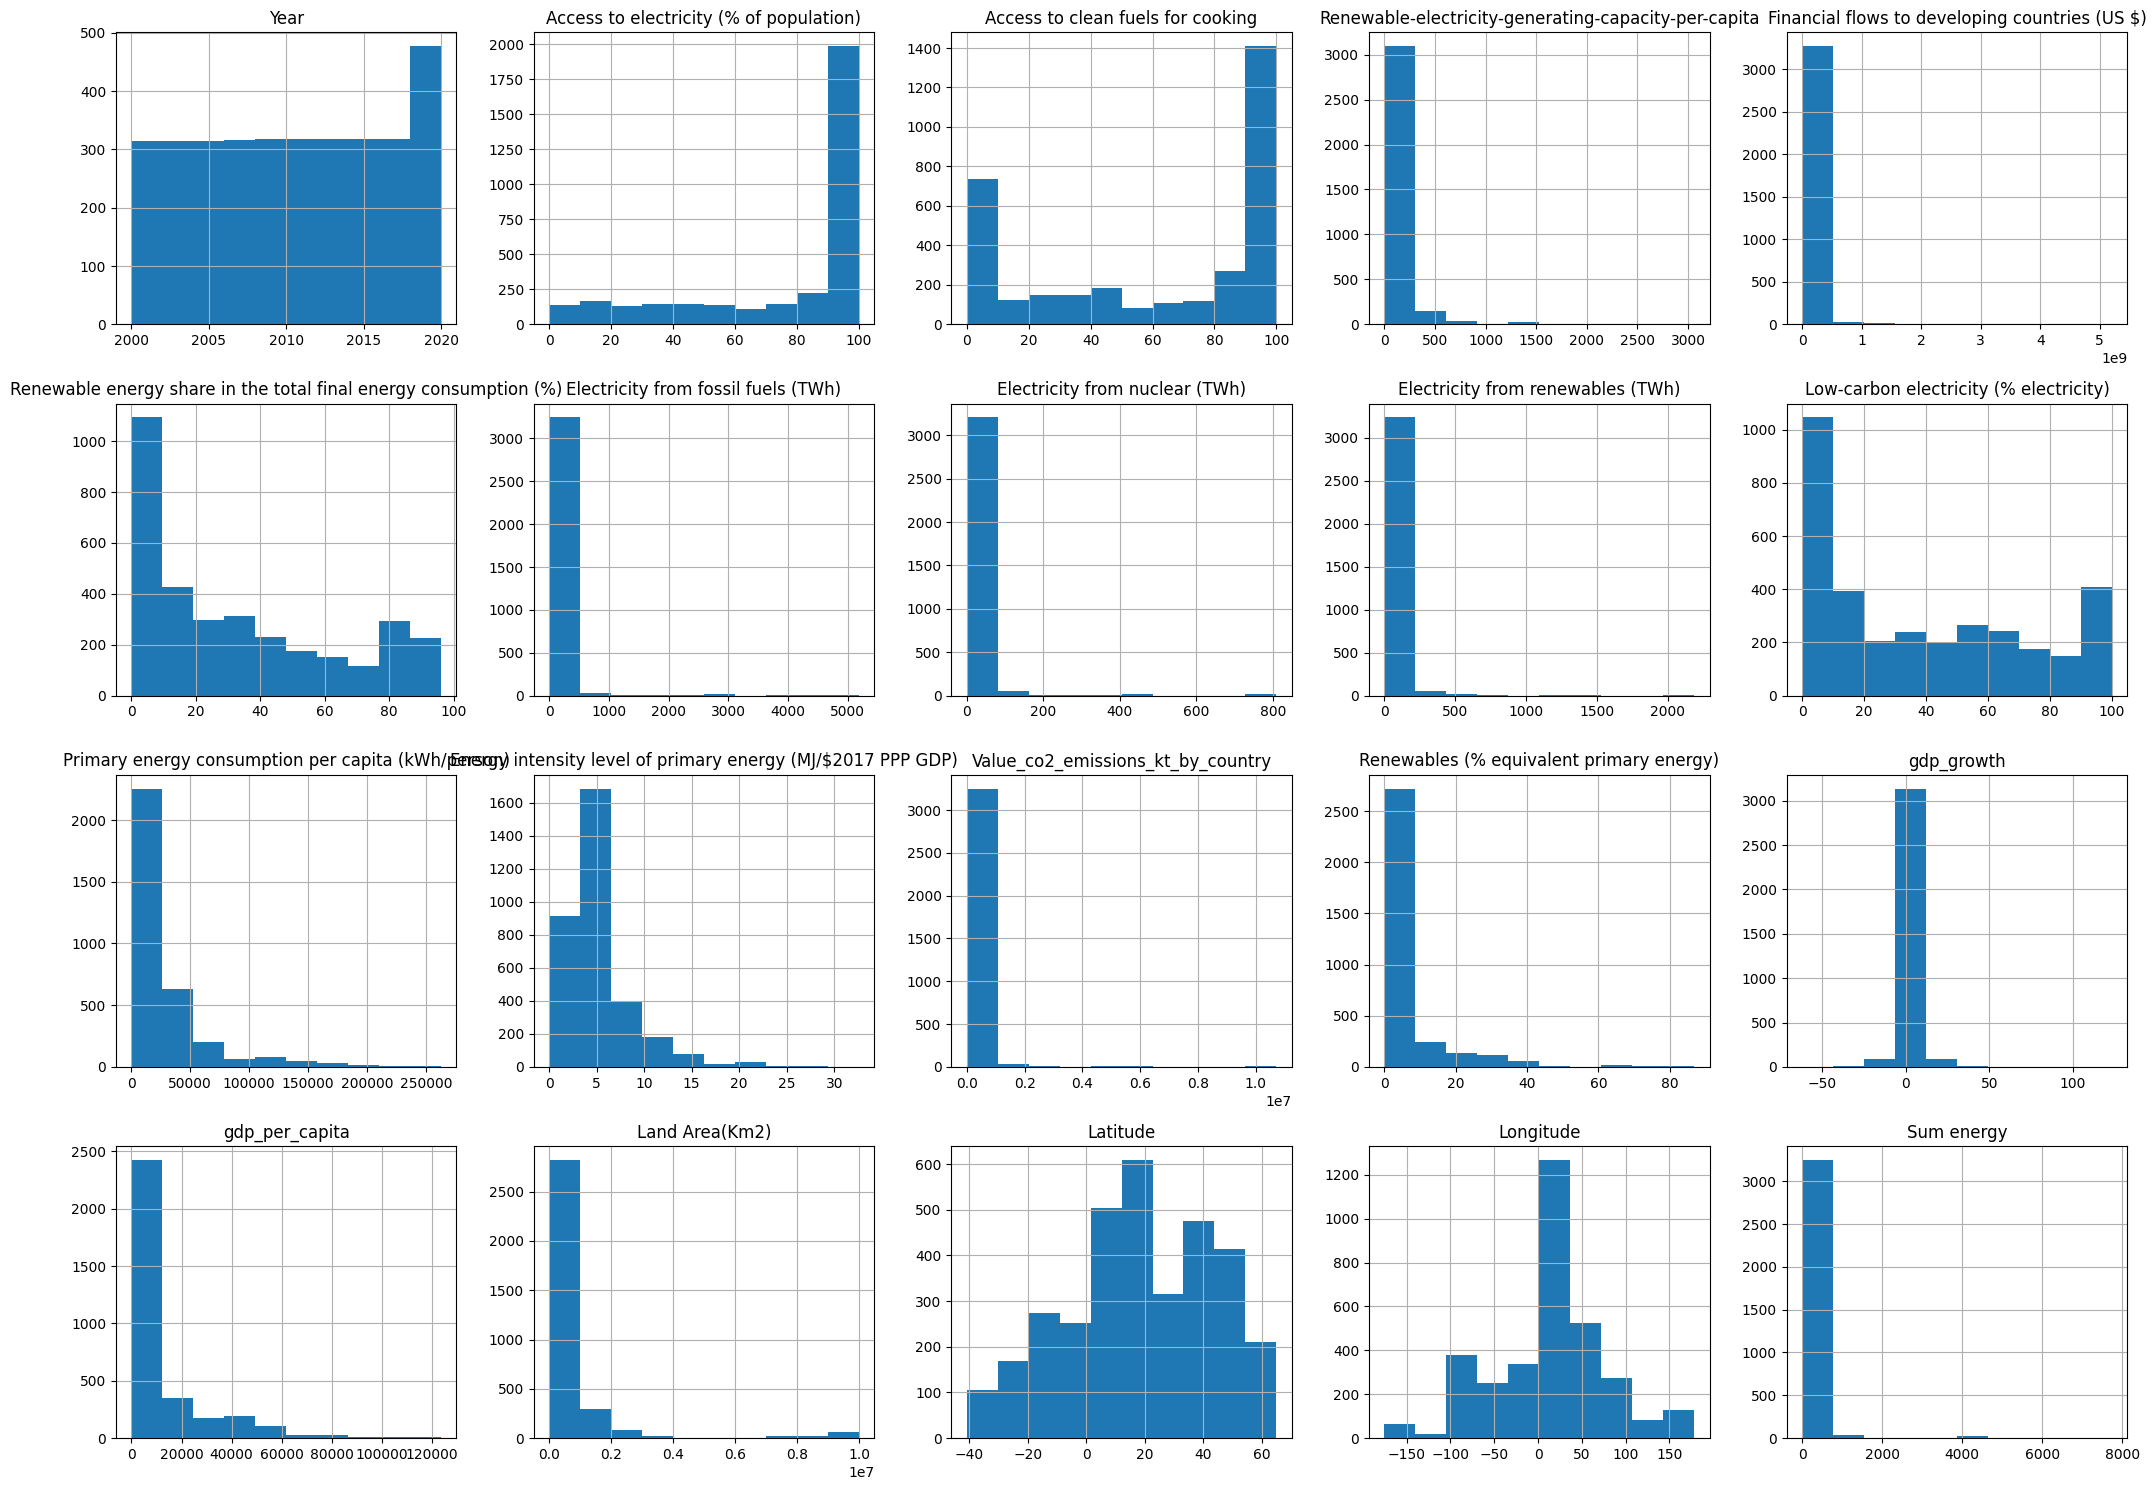

In [ ]:
df2.hist(figsize=(21, 15), layout=(4, 5))
plt.tight_layout()


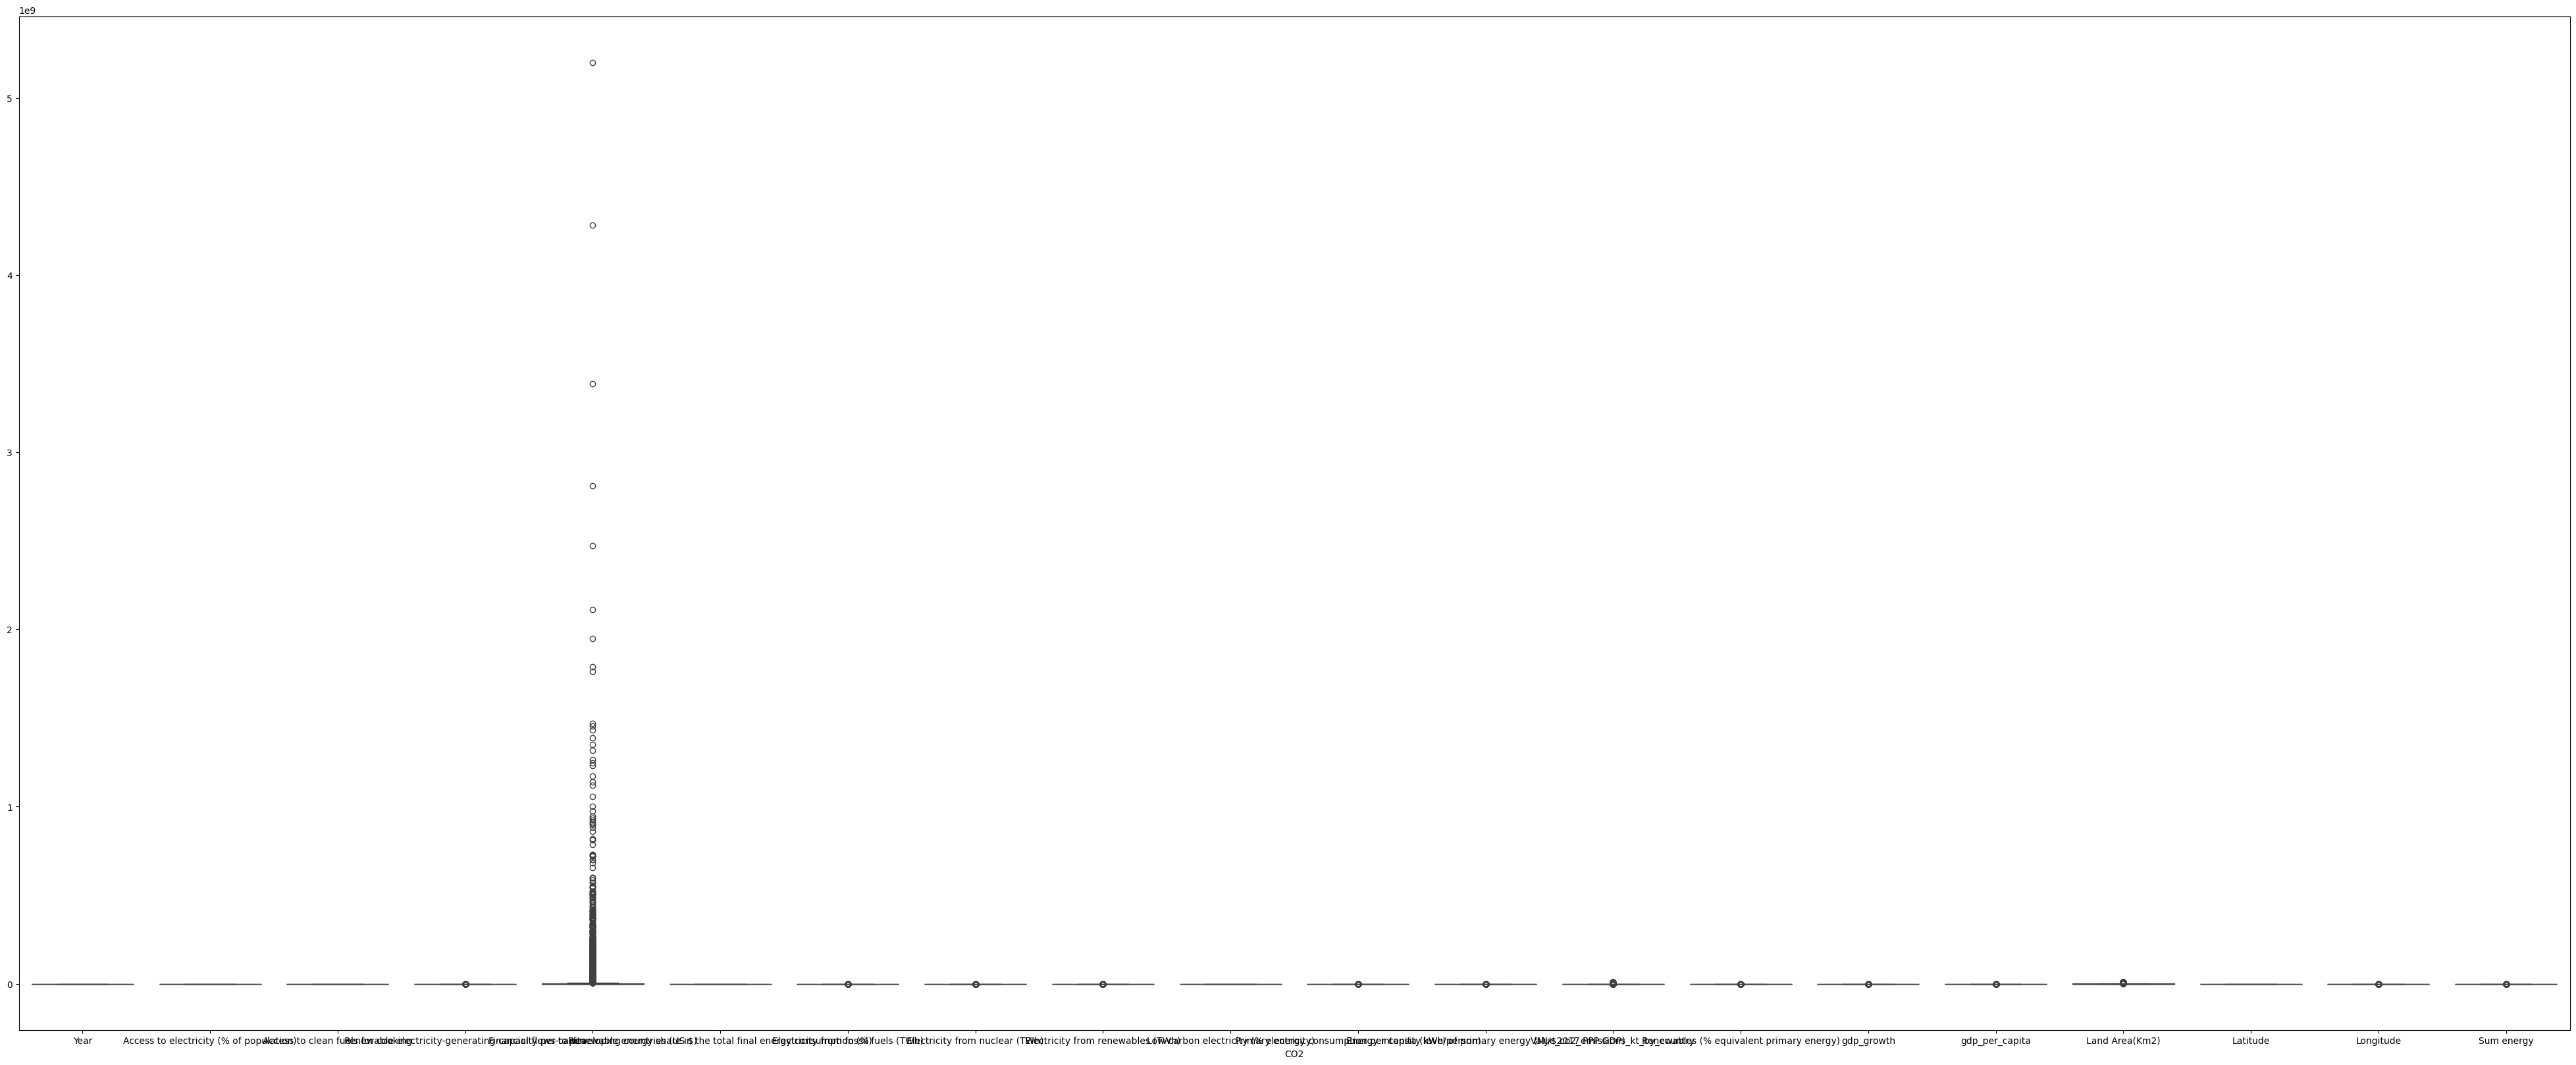

In [ ]:
plt.figure(figsize=(50, 20))
sns.boxplot(df2)

plt.xlabel('CO2')

plt.show()

построим боксплот с признаком СО2 и посмотрим какие выбросы





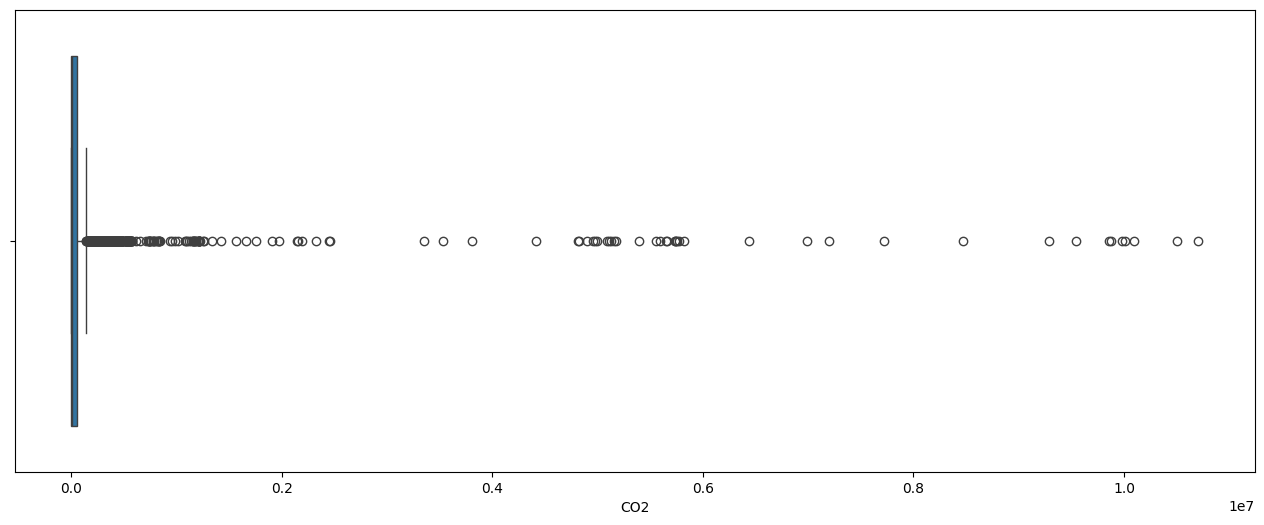

In [ ]:

plt.figure(figsize=(16, 6))
sns.boxplot(x=df2['Value_co2_emissions_kt_by_country'])

plt.xlabel('CO2')

plt.show()

посмотрим разброс данных энергии и выбросы по странам,
построим боксплоты




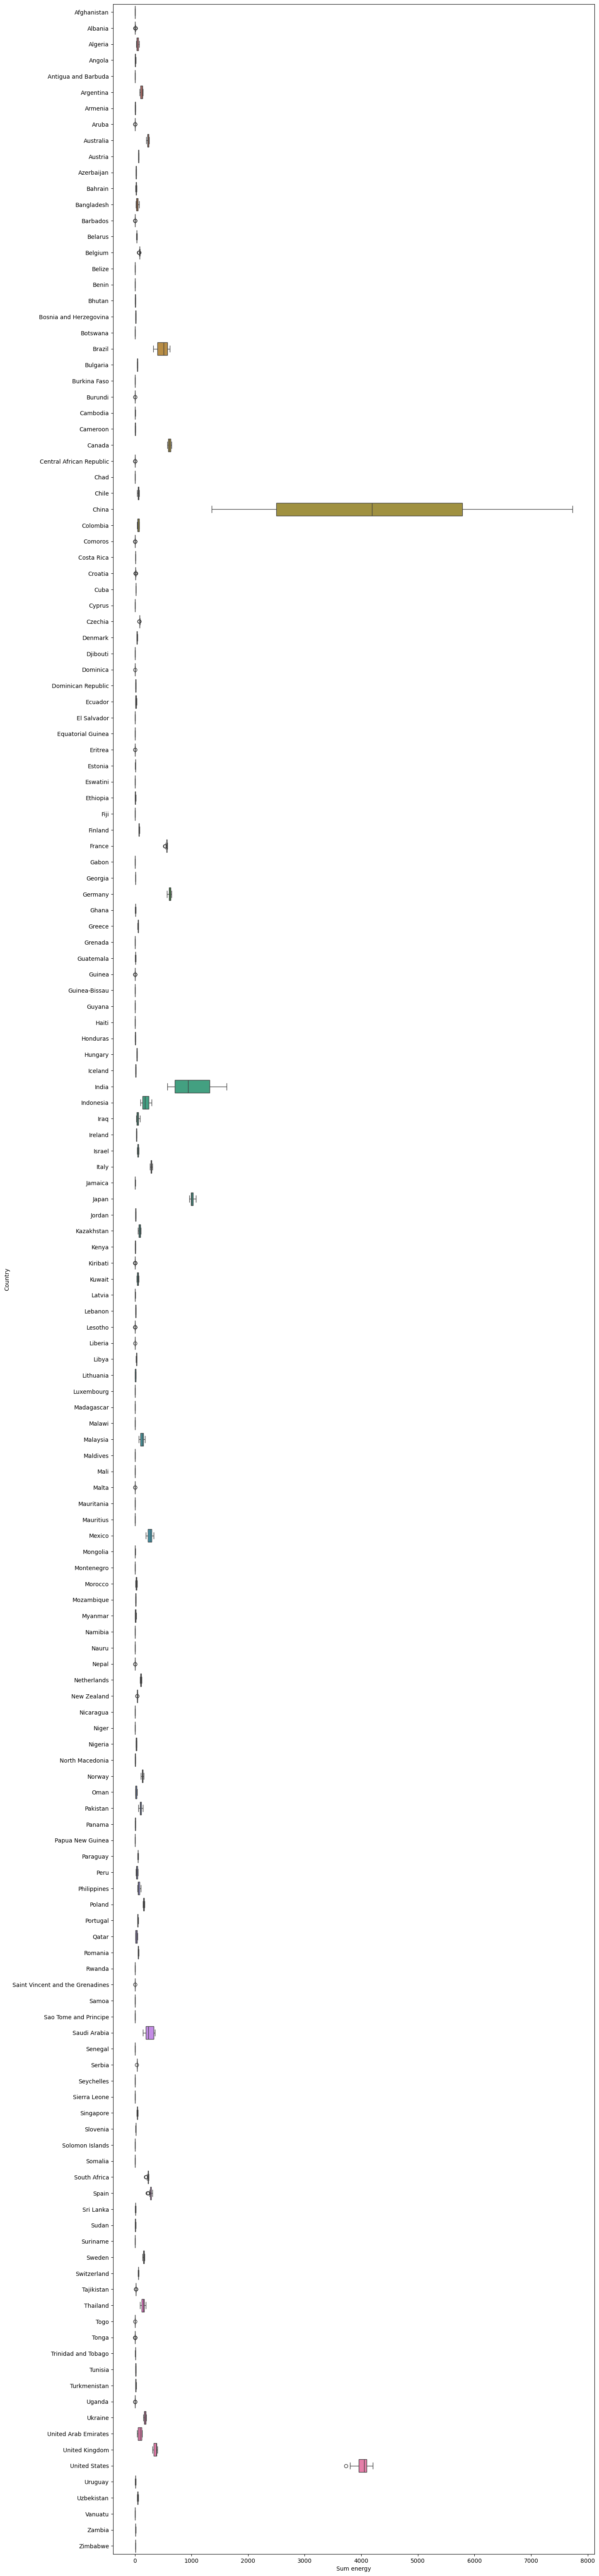

In [ ]:

plt.figure(figsize=(15,80))
sns.boxplot(data=df2, x='Sum energy', y='Country', hue='Country')
plt.show()

удалим колонку со странами

In [ ]:
del df2['Country']

In [ ]:
df2

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),...,Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude,Sum energy
0,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,65.957440,...,1.64,760.000000,0.0,0.000000,0.000000,60,652230.0,33.939110,67.709953,0.47
1,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,84.745766,...,1.74,730.000000,0.0,0.000000,0.000000,60,652230.0,33.939110,67.709953,0.59
2,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,81.159424,...,1.40,1029.999971,0.0,0.000000,179.426579,60,652230.0,33.939110,67.709953,0.69
3,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,67.021280,...,1.40,1220.000029,0.0,8.832278,190.683814,60,652230.0,33.939110,67.709953,0.94
4,2004,20.064968,10.9,7.75,0.0,44.24,0.33,0.0,0.56,62.921350,...,1.20,1029.999971,0.0,1.414118,211.382074,60,652230.0,33.939110,67.709953,0.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3320,2016,42.561730,29.8,62.88,30000.0,81.90,3.50,0.0,3.32,48.680350,...,10.00,11020.000460,0.0,0.755869,1464.588957,38,390757.0,-19.015438,29.154857,6.82
3321,2017,44.178635,29.8,62.33,5570000.0,82.46,3.05,0.0,4.30,58.503407,...,9.51,10340.000150,0.0,4.709492,1235.189032,38,390757.0,-19.015438,29.154857,7.35
3322,2018,45.572647,29.9,82.53,10000.0,80.23,3.73,0.0,5.46,59.412407,...,9.83,12380.000110,0.0,4.824211,1254.642265,38,390757.0,-19.015438,29.154857,9.19
3323,2019,46.781475,30.1,81.40,250000.0,81.50,3.66,0.0,4.58,55.582527,...,10.47,11760.000230,0.0,-6.144236,1316.740657,38,390757.0,-19.015438,29.154857,8.24


#Нормализация данных

In [ ]:

scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(df2)

normalized_data_df=pd.DataFrame(data=normalized_data,columns=['Year', 'Access to electricity (% of population)',
       'Access to clean fuels for cooking',
       'Renewable-electricity-generating-capacity-per-capita',
       'Financial flows to developing countries (US $)',
       'Renewable energy share in the total final energy consumption (%)',
       'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)',
       'Electricity from renewables (TWh)',
       'Low-carbon electricity (% electricity)',
       'Primary energy consumption per capita (kWh/person)',
       'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
       'Value_co2_emissions_kt_by_country',
       'Renewables (% equivalent primary energy)', 'Density\n(P/Km2)', 'gdp_growth',
       'gdp_per_capita', 'Density', 'Land Area(Km2)', 'Latitude', 'Longitude'])


In [ ]:
df2 = normalized_data_df

In [ ]:
df2["Sum energy"] = df2["Electricity from fossil fuels (TWh)"] + df2["Electricity from nuclear (TWh)"] + df2["Electricity from renewables (TWh)"]
df2

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),...,Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),Density\n(P/Km2),gdp_growth,gdp_per_capita,Density,Land Area(Km2),Latitude,Longitude,Sum energy
0,0.00,0.016136,0.062,0.003013,0.000004,0.468451,0.000031,0.0,0.000142,0.659574,...,0.000071,0.0,0.335155,0.000000,0.088093,0.065321,0.706944,0.687612,0.000059,0.000173
1,0.05,0.040746,0.072,0.002895,0.000025,0.474802,0.000017,0.0,0.000229,0.847458,...,0.000068,0.0,0.335155,0.000000,0.088093,0.065321,0.706944,0.687612,0.000075,0.000246
2,0.10,0.094092,0.082,0.002768,0.000759,0.393898,0.000025,0.0,0.000256,0.811594,...,0.000096,0.0,0.335155,0.001453,0.088093,0.065321,0.706944,0.687612,0.000088,0.000281
3,0.15,0.147385,0.095,0.002644,0.004992,0.381716,0.000060,0.0,0.000288,0.670213,...,0.000114,0.0,0.382842,0.001544,0.088093,0.065321,0.706944,0.687612,0.000120,0.000348
4,0.20,0.200650,0.109,0.002533,0.000000,0.460641,0.000064,0.0,0.000256,0.629213,...,0.000096,0.0,0.342790,0.001711,0.088093,0.065321,0.706944,0.687612,0.000114,0.000320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3320,0.80,0.425617,0.298,0.020548,0.000006,0.852770,0.000675,0.0,0.001519,0.486803,...,0.001029,0.0,0.339236,0.011858,0.055097,0.039134,0.206729,0.578473,0.000880,0.002195
3321,0.85,0.441786,0.298,0.020368,0.001071,0.858601,0.000588,0.0,0.001968,0.585034,...,0.000966,0.0,0.360582,0.010000,0.055097,0.039134,0.206729,0.578473,0.000949,0.002556
3322,0.90,0.455726,0.299,0.026969,0.000002,0.835381,0.000720,0.0,0.002499,0.594124,...,0.001156,0.0,0.361202,0.010158,0.055097,0.039134,0.206729,0.578473,0.001187,0.003218
3323,0.95,0.467815,0.301,0.026600,0.000048,0.848605,0.000706,0.0,0.002096,0.555825,...,0.001098,0.0,0.301982,0.010661,0.055097,0.039134,0.206729,0.578473,0.001064,0.002802


Посмотрим парные зависимости признаков после нормализации с использованием Pairplot

In [ ]:
sns.pairplot(df2,
    aspect=.95)

Output hidden; open in https://colab.research.google.com to view.

гистограмма всех признаков после нормализации

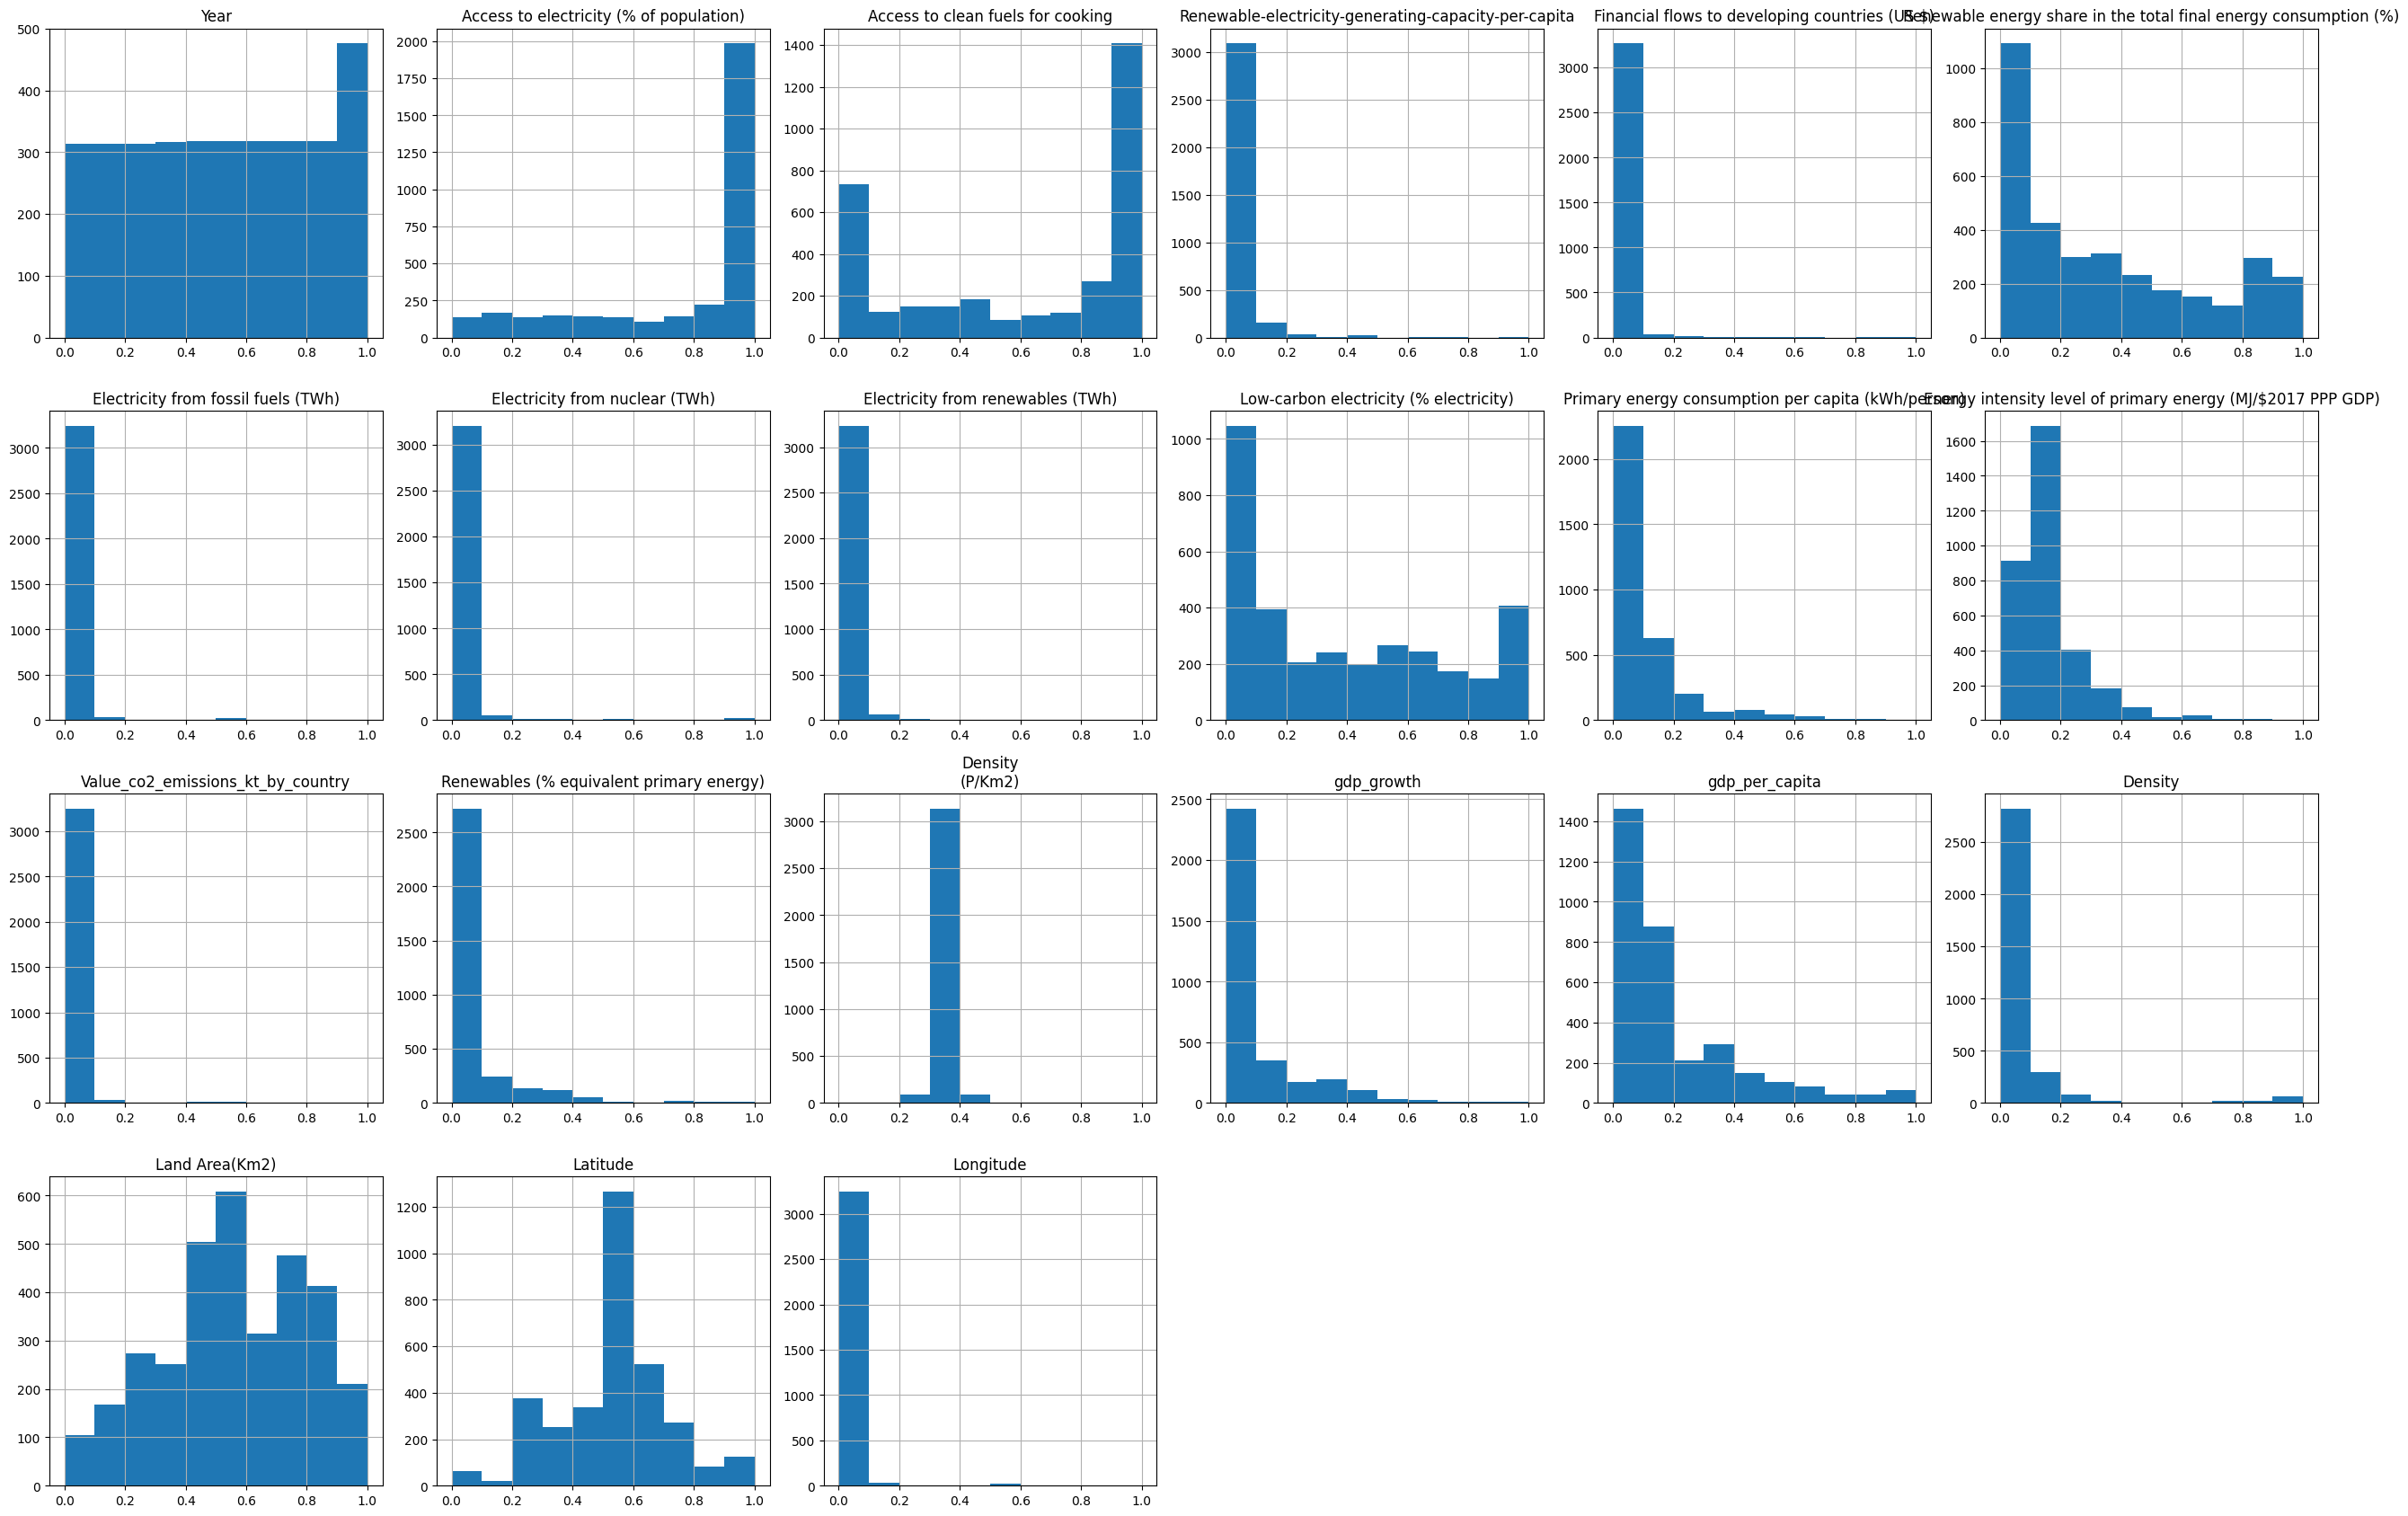

In [ ]:
df2.hist(figsize=(26, 21), layout=(5, 6))
plt.tight_layout()

боксплоты всех признаков

<Axes: >

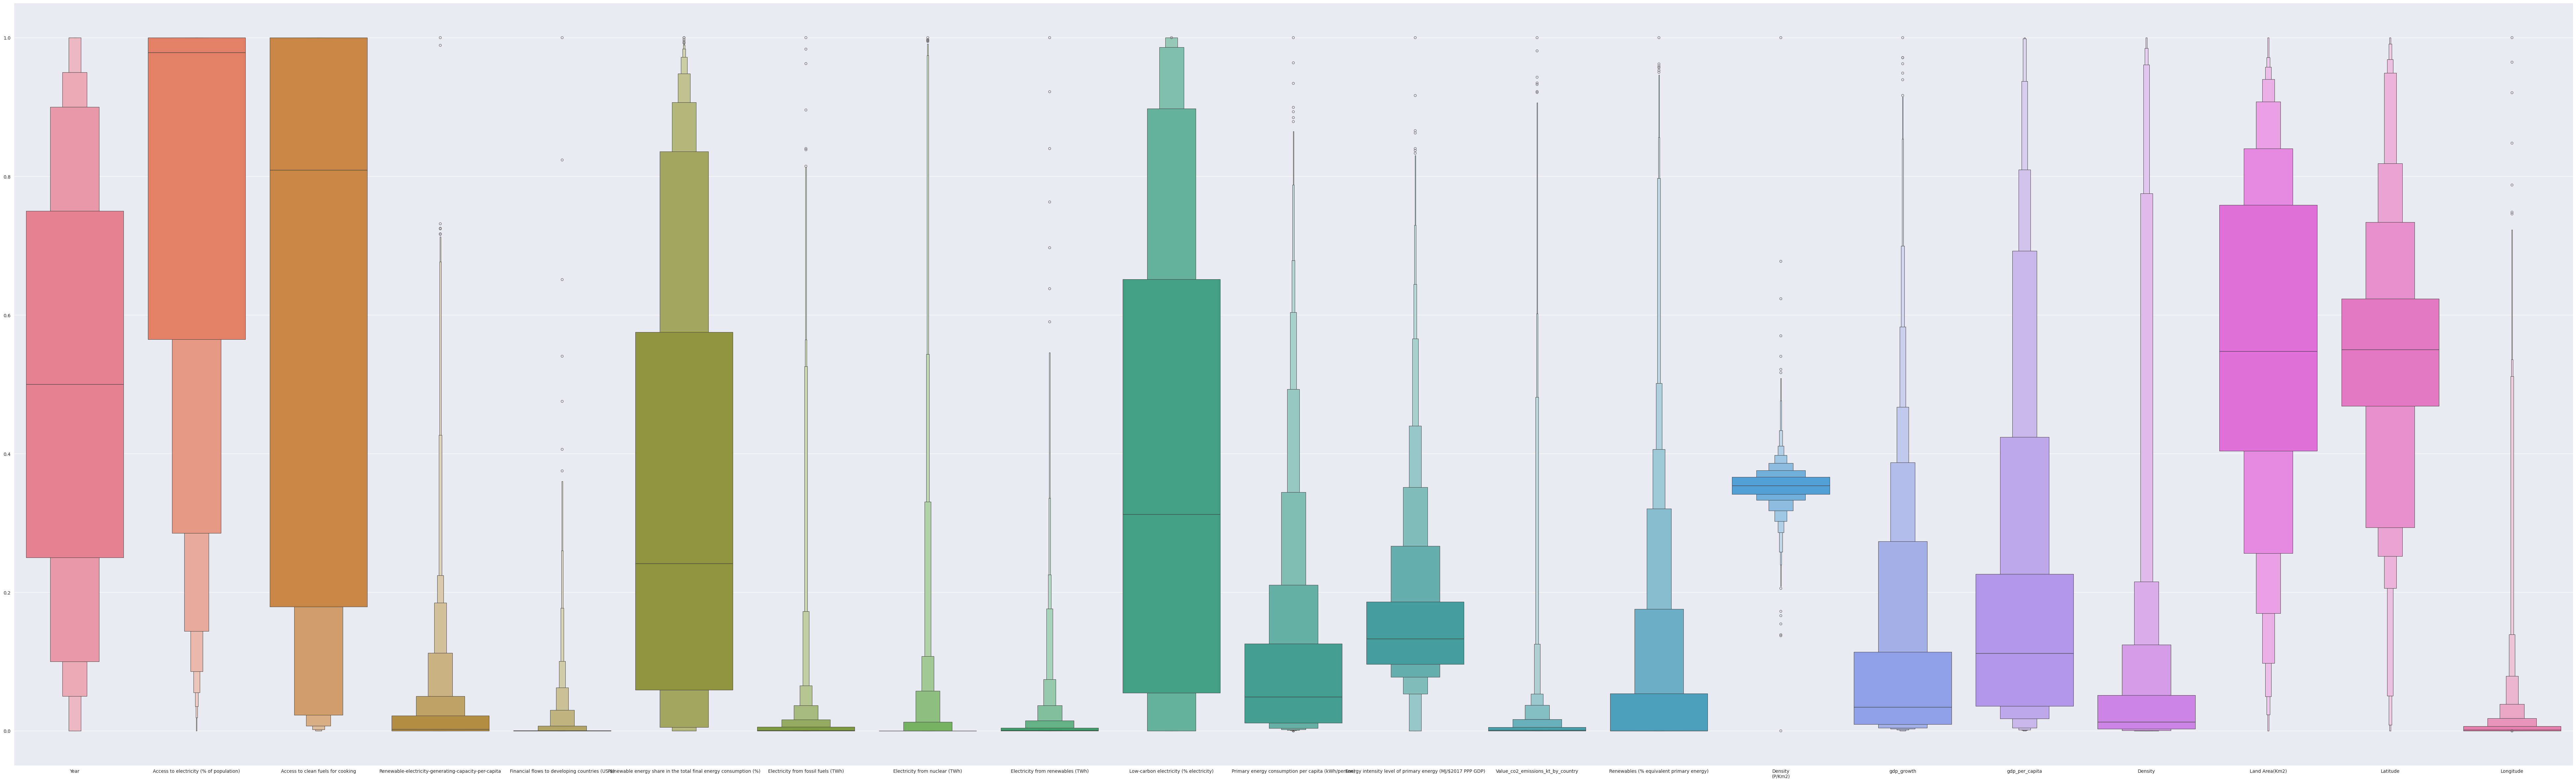

In [ ]:
plt.figure(figsize=(100,30))

sns.boxenplot(df2)

построим матрицу корреляции признаков

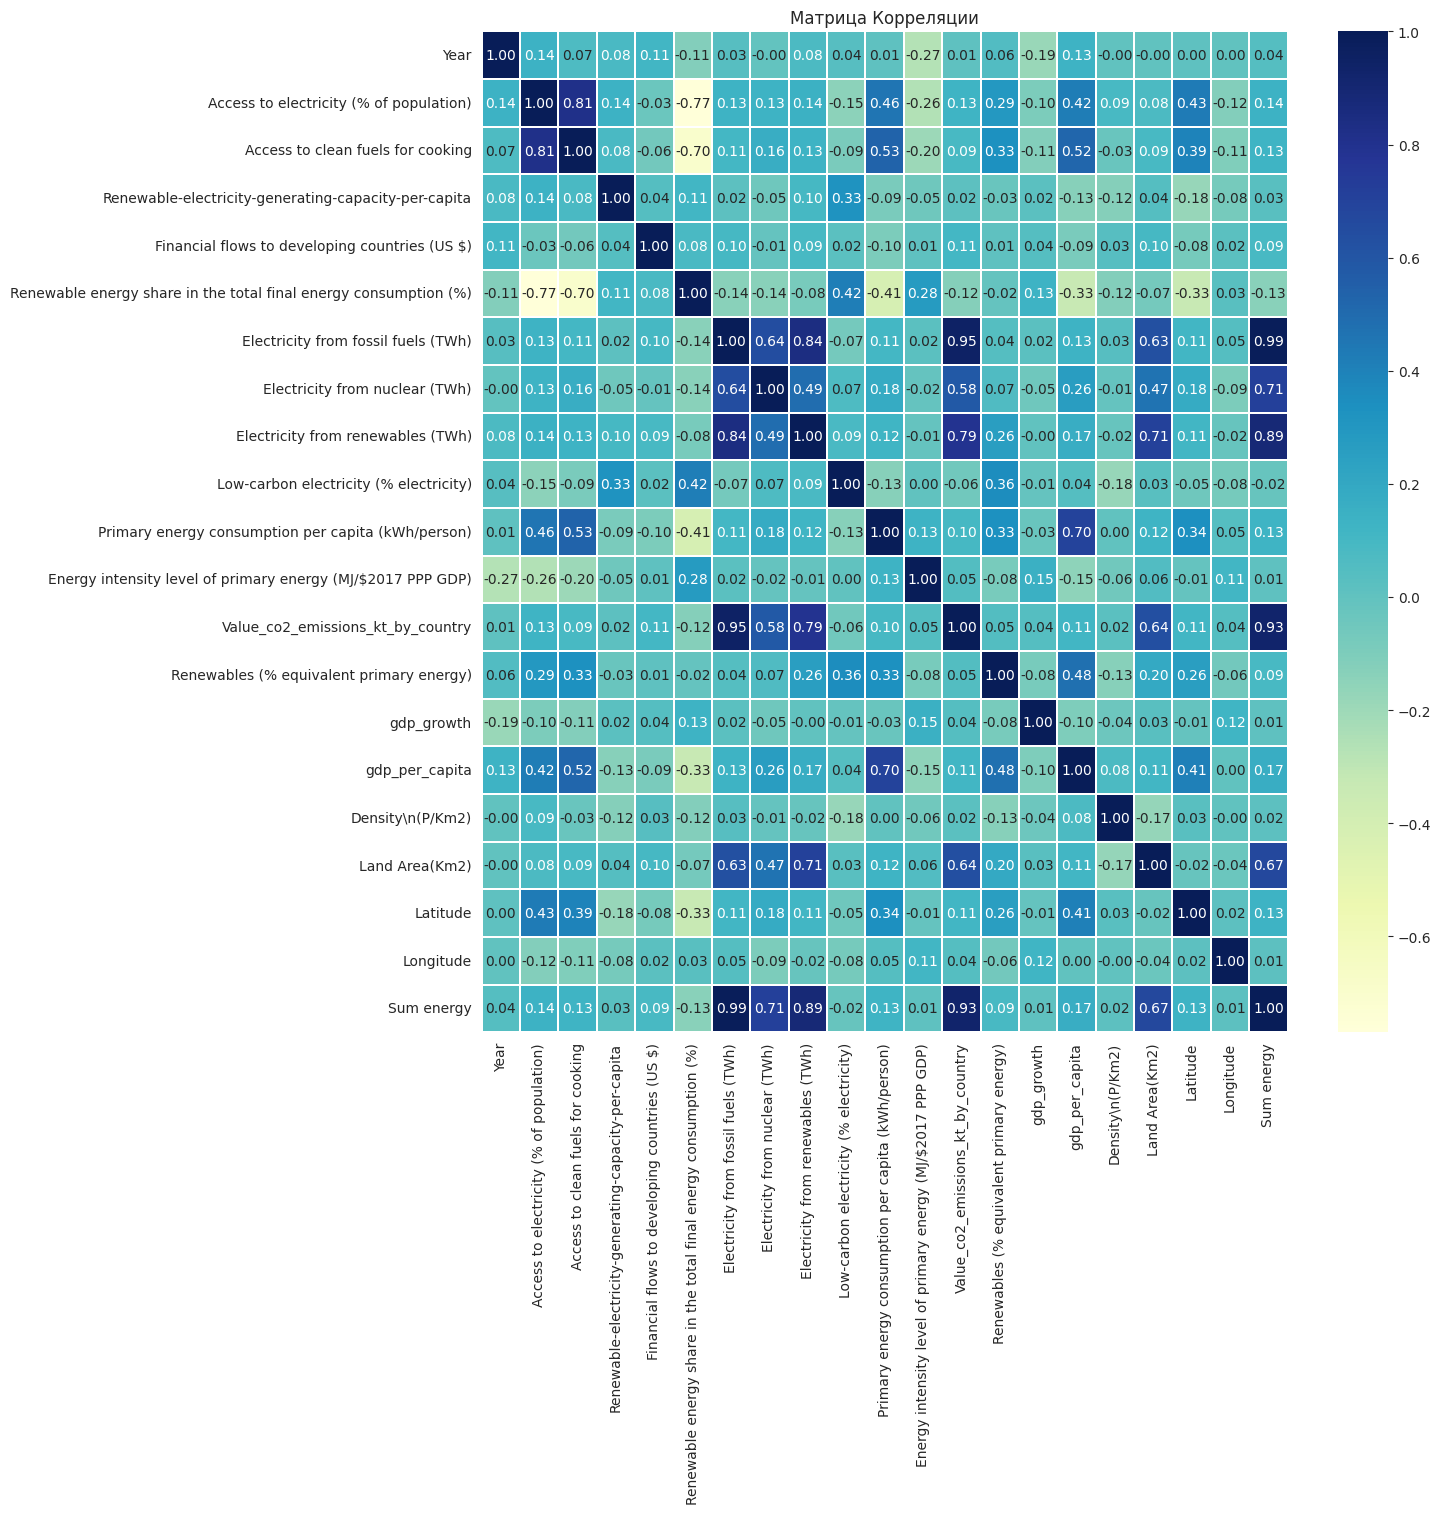

In [ ]:
figsize = (13,13)

fig, ax = plt.subplots(figsize=figsize)
plt.title('Матрица Корреляции')

sns.heatmap(df2.corr(), annot=True,fmt='.2f', linewidth=0.1, cmap='YlGnBu')

plt.show()

создадим датасет с признаками Value_co2_emissions_kt_by_country, Electricity from fossil fuels, Electricity from nuclear, Electricity from renewables, Sum energy, Country и Year

In [ ]:
del df2['Access to electricity (% of population)']
del df2['Access to clean fuels for cooking']
del df2['Renewable-electricity-generating-capacity-per-capita']
del df2['Financial flows to developing countries (US $)']
del df2['Renewable energy share in the total final energy consumption (%)']
del df2['Low-carbon electricity (% electricity)']
del df2['Primary energy consumption per capita (kWh/person)']
del df2['Energy intensity level of primary energy (MJ/$2017 PPP GDP)']
del df2['Renewables (% equivalent primary energy)']
del df2['Density\n(P/Km2)']
del df2['gdp_growth']
del df2['gdp_per_capita']
del df2['Density']
del df2['Land Area(Km2)']
del df2['Latitude']
del df2['Longitude']

я создала датасет с необходимыми мне признаками в отдельный файл.

In [ ]:
df1=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Bauman_Global Dataset/normalized_4Cols2_NewCarbon.csv")


#Применение Label Encoding
преобразование категориальных данных столбца Страны в числовой формат

In [ ]:
df1=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Bauman_Global Dataset/normalized_4Cols2_NewCarbon.csv")


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df1['Country_lable'] = le.fit_transform(df1['Country'])
df1

,Country,Year,Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Value_co2_emissions_kt_by_country,Sum energy,Country_lable
0,Afghanistan,0.00,0.000031,0.0,0.000142,0.000071,0.000059,0
1,Afghanistan,0.05,0.000017,0.0,0.000229,0.000068,0.000075,0
2,Afghanistan,0.10,0.000025,0.0,0.000256,0.000096,0.000088,0
3,Afghanistan,0.15,0.000060,0.0,0.000288,0.000114,0.000120,0
4,Afghanistan,0.20,0.000064,0.0,0.000256,0.000096,0.000114,0
...,...,...,...,...,...,...,...,...
3299,Zimbabwe,0.80,0.000675,0.0,0.001519,0.001029,0.000880,157
3300,Zimbabwe,0.85,0.000588,0.0,0.001968,0.000966,0.000949,157
3301,Zimbabwe,0.90,0.000720,0.0,0.002499,0.001156,0.001187,157
3302,Zimbabwe,0.95,0.000706,0.0,0.002096,0.001098,0.001064,157


##Балансировка данных, применение метода SMOTE

In [ ]:
X = df1.drop('Country', axis=1)
y = df1['Country']

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_resampled, y_resampled = smote.fit_resample(X, y)

In [ ]:
X_resampled

,Year,Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Value_co2_emissions_kt_by_country,Sum energy,Country_lable
0,0.000000,0.000031,0.0,0.000142,0.000071,0.000059,0
1,0.050000,0.000017,0.0,0.000229,0.000068,0.000075,0
2,0.100000,0.000025,0.0,0.000256,0.000096,0.000088,0
3,0.150000,0.000060,0.0,0.000288,0.000114,0.000120,0
4,0.200000,0.000064,0.0,0.000256,0.000096,0.000114,0
...,...,...,...,...,...,...,...
3313,0.565769,0.005219,0.0,0.005107,0.004373,0.004939,127
3314,0.437037,0.005245,0.0,0.004708,0.004449,0.004844,127
3315,0.821903,0.005302,0.0,0.004656,0.004384,0.004867,127
3316,0.831373,0.005331,0.0,0.004924,0.003671,0.004962,127


In [ ]:
del X_resampled['Year']

Разделим датасет на test, val и train выборки

In [ ]:
from sklearn.model_selection import train_test_split

X = X_resampled.drop('Value_co2_emissions_kt_by_country', axis=1)
y = X_resampled['Value_co2_emissions_kt_by_country']


X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=1)

print(f"Размер тренировочного набора: {X_train.shape}")
print(f"Размер тестового набора: {X_test.shape}")

Размер тренировочного набора: (2123, 5)
Размер тестового набора: (664, 5)


#Машинное обучение



В данном разделе протестируем несколько моделей и по характеристике mse выберем лучшую модель для решения поставленной задачи прогноза углекислого газа

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from sklearn.svm import LinearSVC, LinearSVR, SVC, SVR, _libsvm
from sklearn.ensemble import IsolationForest
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

In [ ]:


algorithms = [
    LinearRegression(),
    DecisionTreeRegressor(),
    KNeighborsRegressor(),
    XGBRegressor(),
    RandomForestRegressor(),
    LinearSVR(),
    IsolationForest(),
    ExtraTreesRegressor()
]

best_mse = float('inf')
best_model = None


for model in algorithms:

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mse_scores = -cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
    mean_mse = np.mean(mse_scores)

    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"{model.__class__.__name__} - Cross-Validation MSE: {mean_mse}")
    print(f"{model.__class__.__name__}, mae: {mae}")
    print(f"{model.__class__.__name__}, r2: {r2}")

    if mean_mse < best_mse:
        best_mse = mean_mse
        best_model = model


print("\nBest Model:")
print(best_model)
print("Best Cross-Validation MSE:", best_mse)

LinearRegression - Cross-Validation MSE: 0.0007476222747721707
LinearRegression, mae: 0.004447387310079374
LinearRegression, r2: 0.23632898684566783
DecisionTreeRegressor - Cross-Validation MSE: 0.0023462831934582306
DecisionTreeRegressor, mae: 0.0026327019128744907
DecisionTreeRegressor, r2: 0.3386389706613927
KNeighborsRegressor - Cross-Validation MSE: 0.1834475811453475
KNeighborsRegressor, mae: 0.002269861085079304
KNeighborsRegressor, r2: 0.3982496126261431
XGBRegressor - Cross-Validation MSE: 0.003126327357113211
XGBRegressor, mae: 0.0020276317774596373
XGBRegressor, r2: 0.7855836023479634
RandomForestRegressor - Cross-Validation MSE: 0.0009418416909305445
RandomForestRegressor, mae: 0.0024227422602679963
RandomForestRegressor, r2: 0.35845428826316683


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

LinearSVR - Cross-Validation MSE: 0.0008041605795056532
LinearSVR, mae: 0.0036522470323736675
LinearSVR, r2: 0.13141801185522706
IsolationForest - Cross-Validation MSE: 1.0253847944006496
IsolationForest, mae: 1.0051400894153315
IsolationForest, r2: -436.6118951474959
ExtraTreesRegressor - Cross-Validation MSE: 0.0007277946021579662
ExtraTreesRegressor, mae: 0.0023319769684464506
ExtraTreesRegressor, r2: 0.3516134626655413

Best Model:
ExtraTreesRegressor()
Best Cross-Validation MSE: 0.0007277946021579662


In [ ]:
predictions[:5]

array([0.00133726, 0.00061724, 0.00583019, 0.00093681, 0.00202999])

In [ ]:
y_test[:5]

,Value_co2_emissions_kt_by_country
2753,0.001298
1144,0.000497
2068,0.005932
2034,0.002013
893,0.001953


тестирование линейной модели на разных данных показало, что с методами нормирования, SMOTE и Label Encoding модель предсказывает лучше.

построим график, который демонстрирует тестовые значения и предсказанные.
Лучшие модели LinearRegression и ExtraTreesRegressor

In [ ]:

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
predictions_linear = linear_model.predict(X_test)



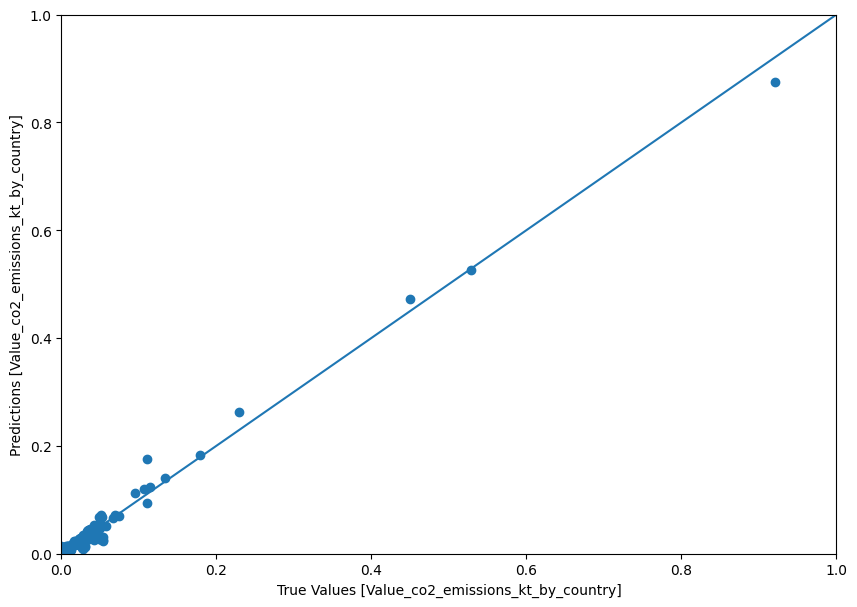

In [ ]:

plt.figure(figsize=(10, 7))

plt.scatter(y_test, predictions_linear)

test_predictions = model.predict(X_test).flatten()

plt.xlabel('True Values [Value_co2_emissions_kt_by_country]')
plt.ylabel('Predictions [Value_co2_emissions_kt_by_country]')

lims = [0, 1]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims)

In [ ]:
linear_model = ExtraTreesRegressor()
linear_model.fit(X_train, y_train)
predictions_linear = linear_model.predict(X_test)

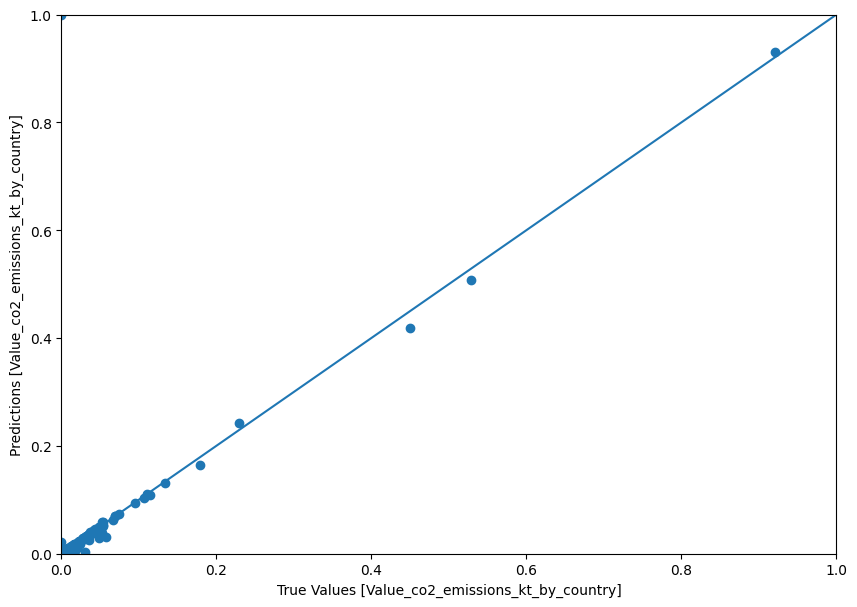

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(y_test, predictions_linear)

test_predictions = model.predict(X_test).flatten()

plt.xlabel('True Values [Value_co2_emissions_kt_by_country]')
plt.ylabel('Predictions [Value_co2_emissions_kt_by_country]')

lims = [0, 1]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims)

Применим метод KMeans, чтобы посмотреть детальнее на данные, на какие кластеры возможно разбить датасет, что из себя представляет многочисленная группа стран с наименьшим потреблением энергии по стравнению с ведущими странами, и создадим точечню диаграмму распределения кластеров.

In [ ]:
df1=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Bauman_Global Dataset/normalized_4Cols2_NewCarbon.csv")


Для этого рассмотрела облачную группу данных без ведущих стран: США, Китай, Индия, Франция, Япония, Англия и Саудовская Аравия

In [ ]:
df1 = df1.set_index('Country')

In [ ]:
df1.drop(['China'],axis = 0, inplace = True)
df1.drop(['India'],axis = 0, inplace = True)
df1.drop(['United Kingdom'],axis = 0, inplace = True)
df1.drop(['Saudi Arabia'],axis = 0, inplace = True)
df1.drop(['United States'],axis = 0, inplace = True)
df1.drop(['Japan'],axis = 0, inplace = True)
df1.drop(['France'],axis = 0, inplace = True)

возврат стран в виде столбца таблицы

In [ ]:
df1 = df1.reset_index('Country')

Удалим столбцы Страны и год, так как нам они не нужны для KMeans

In [ ]:
df1.drop(['Year'],axis = 1, inplace = True)

In [ ]:
df1.drop(['Country'],axis = 1, inplace = True)

In [ ]:
df1

,Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Value_co2_emissions_kt_by_country,Sum energy
0,0.000031,0.0,0.000142,0.000071,0.000059
1,0.000017,0.0,0.000229,0.000068,0.000075
2,0.000025,0.0,0.000256,0.000096,0.000088
3,0.000060,0.0,0.000288,0.000114,0.000120
4,0.000064,0.0,0.000256,0.000096,0.000114
...,...,...,...,...,...
3152,0.000675,0.0,0.001519,0.001029,0.000880
3153,0.000588,0.0,0.001968,0.000966,0.000949
3154,0.000720,0.0,0.002499,0.001156,0.001187
3155,0.000706,0.0,0.002096,0.001098,0.001064


Выделим признаки и целевую переменную Value_co2_emissions_kt_by_country и разделим данные.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split

X = df1.drop('Value_co2_emissions_kt_by_country', axis=1)
y = df1['Value_co2_emissions_kt_by_country']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер тренировочного набора: {X_train.shape}")
print(f"Размер тестового набора: {X_test.shape}")

Размер тренировочного набора: (2525, 4)
Размер тестового набора: (632, 4)


Метод KMeans и график локтя для определения количества оптимальных кластеров

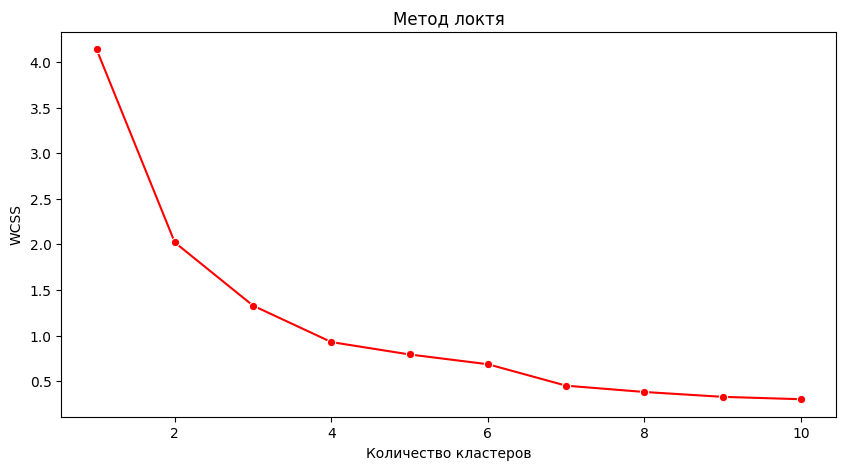

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Создаем пустой список для хранения WCSS
wcss = []

# Перебираем различные количества кластеров от 1 до 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df1)  # Обучаем модель на данных X_train
    wcss.append(kmeans.inertia_)  # inertia_ возвращает значение WCSS для текущего количества кластеров

# Построение графика метода локтя
plt.figure(figsize=(10, 5))
sns.lineplot(x=range(1, 11), y=wcss, marker='o', color='red')
plt.title("Метод локтя")
plt.xlabel("Количество кластеров")
plt.ylabel("WCSS")
plt.show()

Оптимальное количество кластеров 4, распределим данные по 4 кластерам

In [ ]:
from sklearn.cluster import KMeans

#Построение модели KMeans с 4 кластерами
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(df1)  # Получаем метки кластеров

#Добавление меток кластеров в исходные данные
df1['Cluster_id'] = labels  # Добавляем новый столбец 'Cluster_id' к X_train

df1

,Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Value_co2_emissions_kt_by_country,Sum energy,Cluster_id
0,0.000031,0.0,0.000142,0.000071,0.000059,0
1,0.000017,0.0,0.000229,0.000068,0.000075,0
2,0.000025,0.0,0.000256,0.000096,0.000088,0
3,0.000060,0.0,0.000288,0.000114,0.000120,0
4,0.000064,0.0,0.000256,0.000096,0.000114,0
...,...,...,...,...,...,...
3152,0.000675,0.0,0.001519,0.001029,0.000880,0
3153,0.000588,0.0,0.001968,0.000966,0.000949,0
3154,0.000720,0.0,0.002499,0.001156,0.001187,0
3155,0.000706,0.0,0.002096,0.001098,0.001064,0


In [ ]:
#pd.reset_option('display.max_rows', None)


In [ ]:
unique, counts = np.unique(labels, return_counts=True)
print("Количество наблюдений в каждом кластере:", dict(zip(unique, counts)))

Количество наблюдений в каждом кластере: {np.int32(0): np.int64(2823), np.int32(1): np.int64(80), np.int32(2): np.int64(46), np.int32(3): np.int64(208)}


In [ ]:
df1.groupby('Cluster_id').mean()

,Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Value_co2_emissions_kt_by_country,Sum energy
Cluster_id,,,,,
0,0.002029,0.001631,0.002828,0.002162,0.002328
1,0.026828,0.103194,0.030547,0.029569,0.037405
2,0.022759,0.064810,0.175200,0.042454,0.071521
3,0.030311,0.003822,0.012566,0.028257,0.024262


Построение точечной диаграммы с 4 кластерами

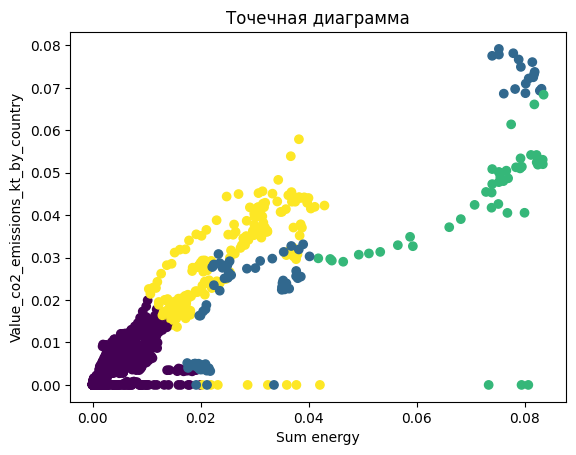

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Создание точечной диаграммы
plt.scatter(df1['Sum energy'], df1['Value_co2_emissions_kt_by_country'], c=labels)

plt.title('Точечная диаграмма')
plt.xlabel('Sum energy')
plt.ylabel('Value_co2_emissions_kt_by_country')

plt.show()

#Создание модели нейронной сети

Применим уже нормированный датасет без методов SMOTE и Label Encoding.
Тестирование модели нейронной сети показало, что лучше применять такие данные.

Построим многойлойный персептрон с активационной функцией relu, на вход подается четыре параметра и на выходе предсказание.

In [30]:
df1=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Bauman_Global Dataset/normalized_4Cols2_NewCarbon.csv")


In [31]:
del df1['Country']
del df1['Year']

In [4]:
df1

,Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Value_co2_emissions_kt_by_country,Sum energy
0,0.000031,0.0,0.000142,0.000071,0.000059
1,0.000017,0.0,0.000229,0.000068,0.000075
2,0.000025,0.0,0.000256,0.000096,0.000088
3,0.000060,0.0,0.000288,0.000114,0.000120
4,0.000064,0.0,0.000256,0.000096,0.000114
...,...,...,...,...,...
3299,0.000675,0.0,0.001519,0.001029,0.000880
3300,0.000588,0.0,0.001968,0.000966,0.000949
3301,0.000720,0.0,0.002499,0.001156,0.001187
3302,0.000706,0.0,0.002096,0.001098,0.001064


In [153]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split

X = df1.drop('Value_co2_emissions_kt_by_country', axis=1)
y = df1['Value_co2_emissions_kt_by_country']

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.4, random_state=42)

print('Размерность X_train', X_train.shape)
print('Размерность X_val', X_val.shape)
print('Размерность X_test', X_test.shape)


Размерность X_train (1387, 4)
Размерность X_val (925, 4)
Размерность X_test (992, 4)


In [129]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from __future__ import absolute_import, division, print_function, unicode_literals


In [154]:
model = tf.keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(10, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(1)
])

In [155]:
model.compile(optimizer='Adam',
              loss='mae',
              metrics=['mae']
              )

history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    validation_data=(X_val, y_val),
    epochs=1000
)

Epoch 1/1000
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0079 - mae: 0.0079 - val_loss: 0.0062 - val_mae: 0.0062
Epoch 2/1000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0042 - mae: 0.0042 - val_loss: 0.0039 - val_mae: 0.0039
Epoch 3/1000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0023 - mae: 0.0023 - val_loss: 0.0035 - val_mae: 0.0035
Epoch 4/1000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019 - mae: 0.0019 - val_loss: 0.0034 - val_mae: 0.0034
Epoch 5/1000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0023 - mae: 0.0023 - val_loss: 0.0033 - val_mae: 0.0033
Epoch 6/1000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0030 - mae: 0.0030 - val_loss: 0.0032 - val_mae: 0.0032
Epoch 7/1000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0034 - mae: 0.0034 - val_loss: 0.0038 - val_mae: 0.0038
Epoch 8/1000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0023 - mae: 0.0023 - val_loss: 0.0032 - val_mae: 0.0032
Epoch 9/1000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - lo

In [156]:
train_results = model.evaluate(X_train, y_train, verbose=0)
val_results = model.evaluate(X_val, y_val, verbose=0)
test_results = model.evaluate(X_test, y_test, verbose=0)

print('test loss train:', train_results)
print('test loss val:', val_results)
print('test loss test:', test_results)


test loss train: [0.0018080766312777996, 0.0018080766312777996]
test loss val: [0.0030123996548354626, 0.0030123996548354626]
test loss test: [0.002909210044890642, 0.002909210044890642]


In [157]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mae,val_loss,val_mae,epoch
995,0.001724,0.001724,0.002723,0.002723,995
996,0.001744,0.001744,0.002849,0.002849,996
997,0.001847,0.001847,0.002907,0.002907,997
998,0.001781,0.001781,0.002661,0.002661,998
999,0.001774,0.001774,0.003012,0.003012,999


In [158]:
def plot_loss(history):
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')

    plt.xlabel('Эпоха')
    plt.ylabel('MSE [Value_co2_emissions_kt_by_country]')
    plt.legend()
    plt.grid(True)

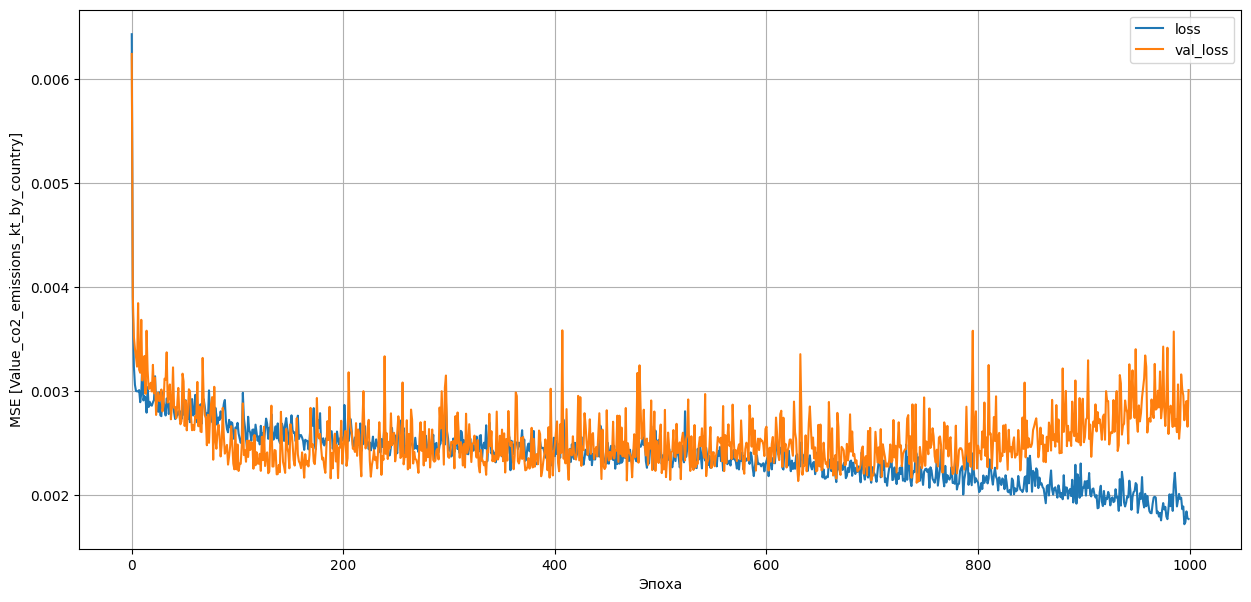

In [159]:
plt.figure(figsize=(15, 7))
plot_loss(history)
plt.show()

In [160]:
def plot_loss(history):
    plt.plot(history.history['mae'], label='metrica')
    plt.plot(history.history['val_mae'], label='val_metrica')

    plt.xlabel('Эпоха')
    plt.ylabel('MAE [Value_co2_emissions_kt_by_country]')
    plt.legend()
    plt.grid(True)

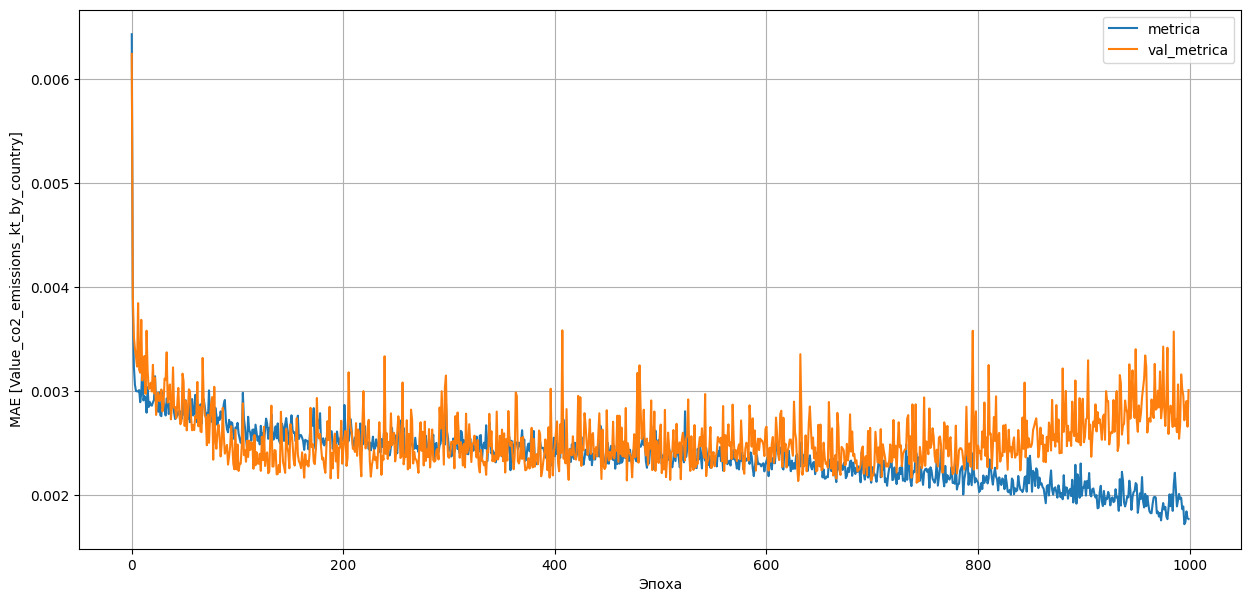

In [161]:
plt.figure(figsize=(15, 7))
plot_loss(history)
plt.show()

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


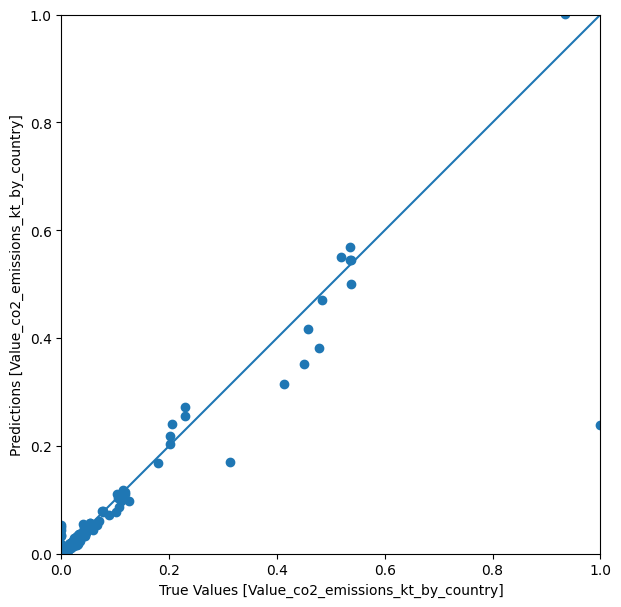

In [162]:
test_predictions = model.predict(X_test).flatten()
#accuracy_score(Y_train_pre, Y_train)
plt.figure(figsize=(15, 7))
a = plt.axes(aspect='equal')
plt.scatter(y_test, test_predictions)
plt.xlabel('True Values [Value_co2_emissions_kt_by_country]')
plt.ylabel('Predictions [Value_co2_emissions_kt_by_country]')

lims = [0, 1]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims)

In [163]:
y_test[:5]

,Value_co2_emissions_kt_by_country
52,0.010664
679,0.005527
969,0.000064
1251,0.001135
203,0.005795


In [164]:
test_predictions[:5]

array([ 7.2878692e-03,  3.1524487e-03, -4.4316985e-05,  6.9834013e-04,
        3.6141733e-03], dtype=float32)

В данном случае предсказания к этому датасету получаются не очень точные. Необходимо учитывать и тестировать многочисленные параметры. Предсказание очень сильно зависит от выборки значений и ее подготовки.

#Приложение

Код модели

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import pickle

df1=pd.read_csv("co2_real.csv")

X = df1.drop('Value_co2_emissions_kt_by_country', axis=1)
y = df1['Value_co2_emissions_kt_by_country']

In [ ]:
minmax_scaler_X = MinMaxScaler()
minmax_scaler_y = MinMaxScaler()

X=pd.DataFrame(data=X,columns=['Electricity from fossil fuels (TWh)','Electricity from nuclear (TWh)','Electricity from renewables (TWh)'])
y=pd.DataFrame(data=y,columns=['Value_co2_emissions_kt_by_country'])

X = minmax_scaler_X.fit_transform(X)
y = minmax_scaler_y.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
co2 = model.predict(X_test)

In [ ]:
pickle.dump(model, open('model.pkl','wb'))

In [ ]:
#ссылка на файлы приложения
https://github.com/zoricheva/Global-Data-CO2/tree/Prediction-CO2

https://global-data-co2-8.onrender.com/

Тест кода для приложения

In [ ]:
X_test = [[2348,0,231]]

In [ ]:
minmax_scaler_X = pickle.load(open('scaler.pkl','rb'))

In [ ]:
X_test=pd.DataFrame(data=X_test,columns=['Electricity from fossil fuels (TWh)','Electricity from nuclear (TWh)','Electricity from renewables (TWh)'])


In [ ]:
X_test = minmax_scaler_X.transform(X_test)
X_test

array([[0.45292074, 0.        , 0.10572373]])

In [ ]:
co2 = model.predict(X_test)
co2

array([[0.48357821]])

In [ ]:
co2 = minmax_scaler_y.inverse_transform(co2)
co2

array([[5177778.16388294]])

Код предобработки данных

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import pickle

df1=pd.read_csv("co2_real.csv")

X = df1.drop('Value_co2_emissions_kt_by_country', axis=1)
y = df1['Value_co2_emissions_kt_by_country']

In [ ]:
minmax_scaler_X = MinMaxScaler()
minmax_scaler_y = MinMaxScaler()

X=pd.DataFrame(data=X,columns=['Electricity from fossil fuels (TWh)','Electricity from nuclear (TWh)','Electricity from renewables (TWh)'])
y=pd.DataFrame(data=y,columns=['Value_co2_emissions_kt_by_country'])

X = minmax_scaler_X.fit_transform(X)
y = minmax_scaler_y.fit_transform(y)

In [ ]:
X_test = minmax_scaler_X.transform(X_test)

In [ ]:
co2 = minmax_scaler_y.inverse_transform(co2)

In [ ]:
pickle.dump(minmax_scaler_X, open('scaler.pkl','wb'))

In [ ]:
pickle.dump(minmax_scaler_y, open('scaler_y.pkl','wb'))

тест кода предобработки данных

In [ ]:
X_test = [[24,543,675]]

In [ ]:
X_test=pd.DataFrame(data=X_test,columns=['Electricity from fossil fuels (TWh)','Electricity from nuclear (TWh)','Electricity from renewables (TWh)'])

In [ ]:
X_test = minmax_scaler_X.transform(X_test)
X_test

array([[0.00462951, 0.67085902, 0.30893297]])

In [ ]:
minmax_scaler_X.inverse_transform(X_test)


array([[ 24., 543., 675.]])

In [ ]:
y_test = [[0.003478]]

In [ ]:
y_test=pd.DataFrame(data=y_test,columns=['Value_co2_emissions_kt_by_country'])

In [ ]:
y_test = minmax_scaler_y.transform(y_test)
y_test

array([[3.24827554e-10]])

In [ ]:
co2 = minmax_scaler_y.inverse_transform(y_test)
co2

array([[0.003478]])